In [ ]:
%pip install plotly==5.23.0

In [9]:
import sklearn.metrics as metrics
from scorer.scorer import CobaldScorer
from common.parse_conllu import parse_conllu_incr
from more_itertools import zip_equal
import plotly.express as px
import numpy as np

NO_SEM_PREDICTIONS_CONLLU = "nosem.conllu"
SEM_PREDICTIONS_CONLLU = "withsem.conllu"
GOLD_CONLLU = "gold.conllu"

In [2]:
NO_REL = '-'


def calc_deps_heads_agreement(test, gold):
    test_heads = set(test.deps.keys())
    gold_heads = set(gold.deps.keys())
    return len(test_heads & gold_heads)


def calc_deps_rels_agreement(test, gold):
    test_deps = set(test.deps.items())
    gold_deps = set(gold.deps.items())
    return len(test_deps & gold_deps)


scorer = CobaldScorer()

deps_rels_no_sem = []
deps_rels_sem = []
deps_rels_gold = []

with open(NO_SEM_PREDICTIONS_CONLLU, 'r') as no_sem_preds_file, open(SEM_PREDICTIONS_CONLLU, 'r') as sem_preds_file, open(GOLD_CONLLU, 'r') as gold_file:
    no_sem_sentences = parse_conllu_incr(no_sem_preds_file)
    sem_sentences = parse_conllu_incr(sem_preds_file)
    gold_sentences = parse_conllu_incr(gold_file)

    for no_sem_sentence, sem_sentence, gold_sentence in zip_equal(no_sem_sentences, sem_sentences, gold_sentences):
        # Align three sentences.
        _, gold_sentence_aligned1 = scorer._align_sentences(no_sem_sentence, gold_sentence)
        _, gold_sentence_aligned2 = scorer._align_sentences(sem_sentence, gold_sentence)
        _, gold_sentence_aligned = scorer._align_sentences(gold_sentence_aligned1, gold_sentence_aligned2)
        no_sem_sentence_aligned, gold_sentence_aligned = scorer._align_sentences(no_sem_sentence, gold_sentence_aligned)
        sem_sentence_aligned, gold_sentence_aligned = scorer._align_sentences(sem_sentence, gold_sentence_aligned)
        assert len(no_sem_sentence_aligned) == len(sem_sentence_aligned) == len(gold_sentence_aligned), \
            f"{no_sem_sentence_aligned.serialize()}\n{sem_sentence_aligned.serialize()}\n{gold_sentence_aligned.serialize()}"

        for no_sem_token, sem_token, gold_token in zip_equal(no_sem_sentence_aligned, sem_sentence_aligned, gold_sentence_aligned):
            is_mismatched = no_sem_token.is_empty() or sem_token.is_empty() or gold_token.is_empty()
            if is_mismatched:
                continue
            
            assert no_sem_token.form == sem_token.form == gold_token.form, \
                f"Error at sent_id={test_sentence.sent_id} : Tokens forms are mismatched."

            for head in (no_sem_token.deps.keys() | sem_token.deps.keys() | gold_token.deps.keys()):
                deps_rels_no_sem.append(no_sem_token.deps[head] if head in no_sem_token.deps else NO_REL)
                deps_rels_sem.append(sem_token.deps[head] if head in sem_token.deps else NO_REL)
                deps_rels_gold.append(gold_token.deps[head] if head in gold_token.deps else NO_REL)

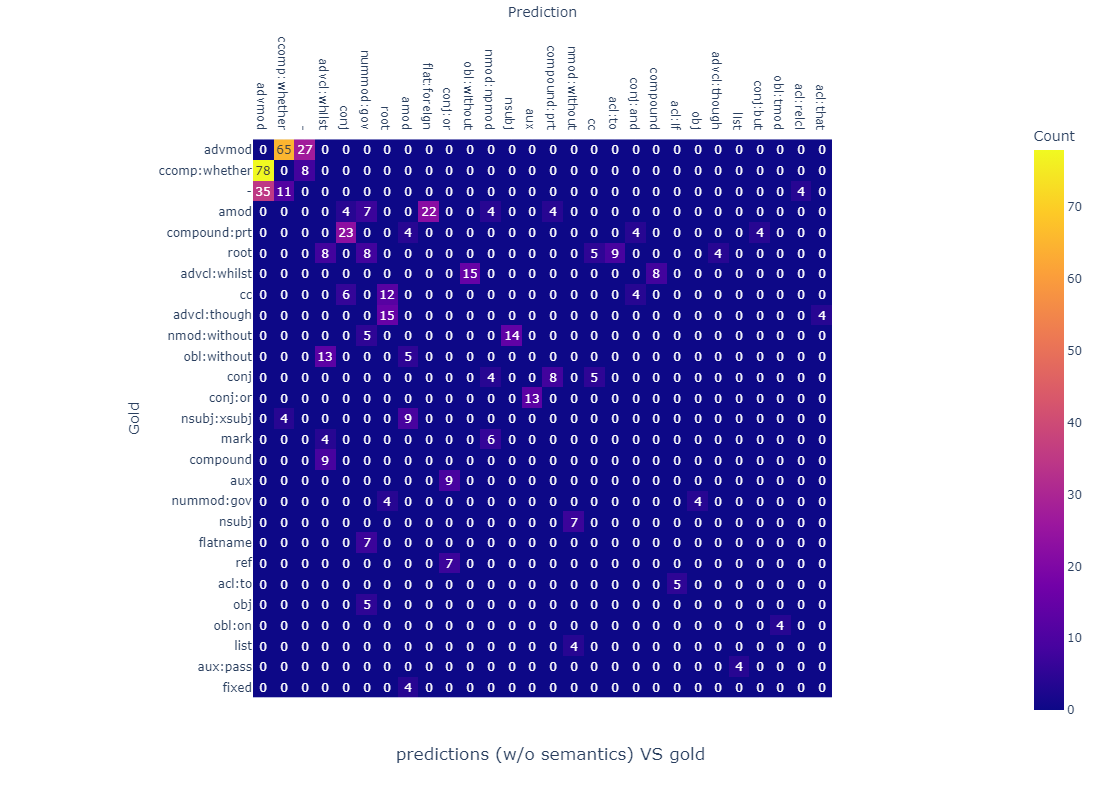

In [103]:
def reorder(arr, indices):
    n = min(len(arr), len(indices))
    result = [0] * n
    for i in range(n):
        result[i] = arr[indices[i]]
    for el in result:
        assert el != 0
    assert len(result) == n
    return result


def visualize_cm(test_dirty, gold_dirty, title=None, x_title="Prediction", y_title="Gold"):
    # Skip synchronous NO_REL in order to normalize confusion matrix
    test_clean, gold_clean = [], []
    for test_rel, gold_rel in zip_equal(test_dirty, gold_dirty):
        if test_rel == NO_REL and gold_rel == NO_REL:
            continue
        test_clean.append(test_rel)
        gold_clean.append(gold_rel)
    deps_rels_tagset = sorted(list(set(test_clean) | set(gold_clean)))
    
    # Visualize
    cm = metrics.confusion_matrix(gold_clean, test_clean, labels=deps_rels_tagset)
    np.fill_diagonal(cm, 0)
    cm = cm[1:, 1:]
    cm[cm < 0.05 * cm.max()] = 0
    # Calculate row and column densities (number of non-zero elements)
    row_densities = np.sum(cm, axis=1)
    column_densities = np.sum(cm, axis=0)
    last_nonzero_row_index = np.count_nonzero(row_densities)
    last_nonzero_column_index = np.count_nonzero(column_densities)
    sorted_row_indices = np.argsort(row_densities)[::-1][:last_nonzero_row_index]  # Descending order
    sorted_column_indices = np.argsort(column_densities)[::-1][:last_nonzero_column_index]  # Descending order
    # Reorder the matrix
    cm = cm[np.ix_(sorted_row_indices, sorted_column_indices)]

    fig = px.imshow(
        cm, text_auto=True,
        y=reorder(deps_rels_tagset, sorted_row_indices), x=reorder(deps_rels_tagset, sorted_column_indices),
        labels=dict(x=x_title, y=y_title, color="Count"),
    )
    fig.update_layout(
        autosize=False,
        width=800, height=800,
        title=title, title_x=0.5, title_y=0.05
    )
    # Update the heatmap to display custom text (hides zeros)
    fig.update_xaxes(side="top")
    fig.show()


visualize_cm(deps_rels_no_sem, deps_rels_gold, "predictions (w/o semantics) VS gold")

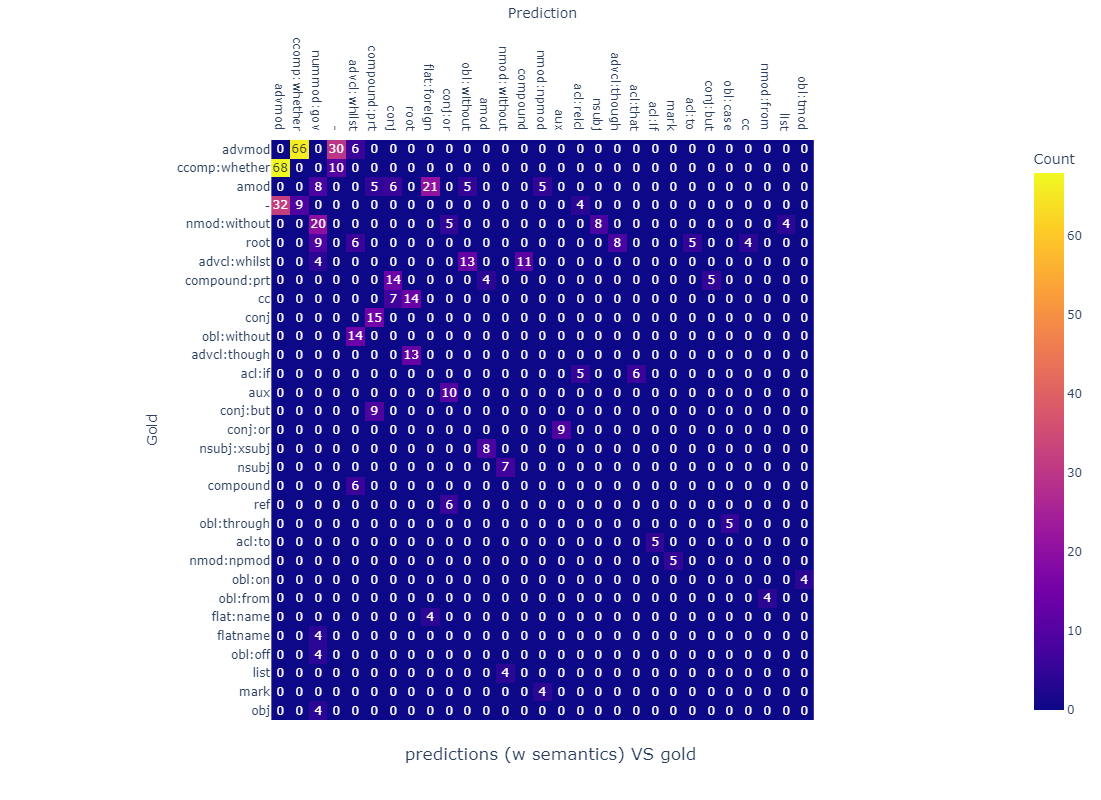

In [104]:
visualize_cm(deps_rels_sem, deps_rels_gold, "predictions (w semantics) VS gold")

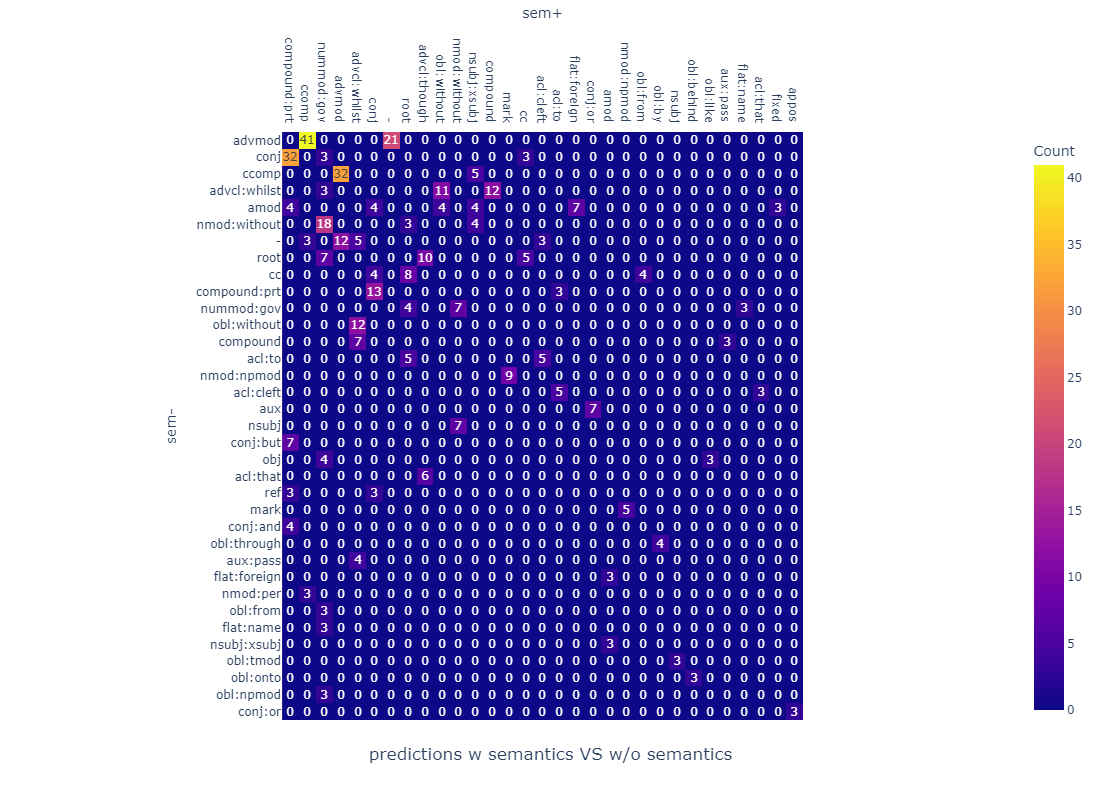

In [105]:
visualize_cm(deps_rels_sem, deps_rels_no_sem, "predictions w semantics VS w/o semantics", x_title="sem+", y_title="sem-")